# Import Libraries...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset...

In [2]:
data = pd.read_csv('data-export (1).csv')
data.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


# Data Cleaning...

In [3]:
data.columns = data.iloc[0]
data = data.drop(index=0).reset_index(drop=True)
data.columns = ['Channel_Group' , 'Date_Hour' , 'Users' , 'Sessions' , 'Engaged_Sessions' , 'Average_Engagement_This_Per_Session', 'Engaged_Sessions_Per_Day' , 'Event_Per_Session' , 'Engagement_Rate' , 'Event_Count']
data.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Average_Engagement_This_Per_Session,Engaged_Sessions_Per_Day,Event_Per_Session,Engagement_Rate,Event_Count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Channel_Group                        3182 non-null   str  
 1   Date_Hour                            3182 non-null   str  
 2   Users                                3182 non-null   str  
 3   Sessions                             3182 non-null   str  
 4   Engaged_Sessions                     3182 non-null   str  
 5   Average_Engagement_This_Per_Session  3182 non-null   str  
 6   Engaged_Sessions_Per_Day             3182 non-null   str  
 7   Event_Per_Session                    3182 non-null   str  
 8   Engagement_Rate                      3182 non-null   str  
 9   Event_Count                          3182 non-null   str  
dtypes: str(10)
memory usage: 248.7 KB


In [5]:
data['Date_Hour'] = pd.to_datetime(data['Date_Hour'] , format='%Y%m%d%H' , errors='coerce')
data.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Average_Engagement_This_Per_Session,Engaged_Sessions_Per_Day,Event_Per_Session,Engagement_Rate,Event_Count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [6]:
numeric_cols = data.columns.drop(['Channel_Group' , 'Date_Hour'])
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric)
data['Hours'] = data['Date_Hour'].dt.hour
data.head()

,Channel_Group,Date_Hour,Users,Sessions,Engaged_Sessions,Average_Engagement_This_Per_Session,Engaged_Sessions_Per_Day,Event_Per_Session,Engagement_Rate,Event_Count,Hours
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel_Group                        3182 non-null   str           
 1   Date_Hour                            3182 non-null   datetime64[us]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged_Sessions                     3182 non-null   int64         
 5   Average_Engagement_This_Per_Session  3182 non-null   float64       
 6   Engaged_Sessions_Per_Day             3182 non-null   float64       
 7   Event_Per_Session                    3182 non-null   float64       
 8   Engagement_Rate                      3182 non-null   float64       
 9   Event_Count                          3182 non-null   int64         
 10  Hours                  

In [8]:
data.describe()

,Date_Hour,Users,Sessions,Engaged_Sessions,Average_Engagement_This_Per_Session,Engaged_Sessions_Per_Day,Event_Per_Session,Engagement_Rate,Event_Count,Hours
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# 1. What Patterns On Trends Can You Observe In Website Sessions And User Over Time?

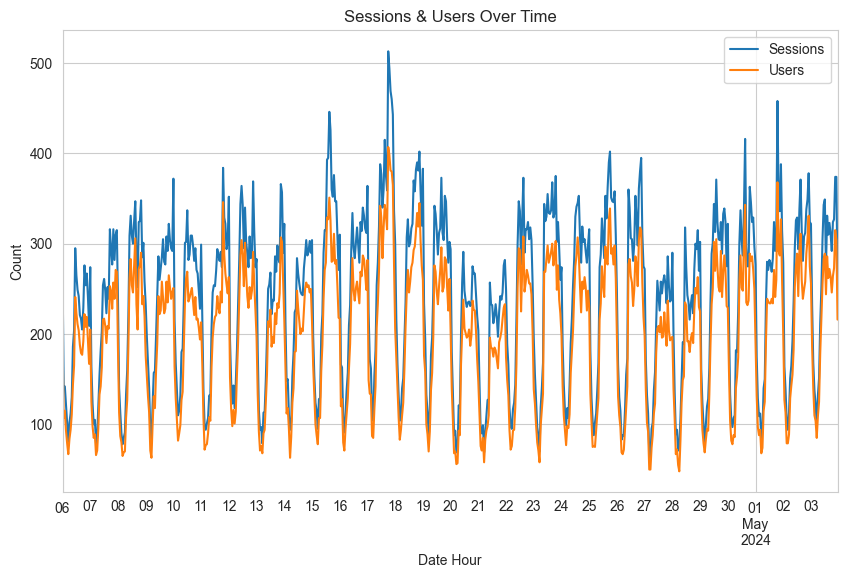

In [9]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
data.groupby('Date_Hour')[['Sessions' , 'Users']].sum().plot(ax = plt.gca())
plt.title('Sessions & Users Over Time')
plt.xlabel('Date Hour')
plt.ylabel('Count')
plt.show()

# 2. Which Marketing Channel Brought The Highest Of Users To The Website And How Can we Use This Insight To Improve Traffic From Other Source?

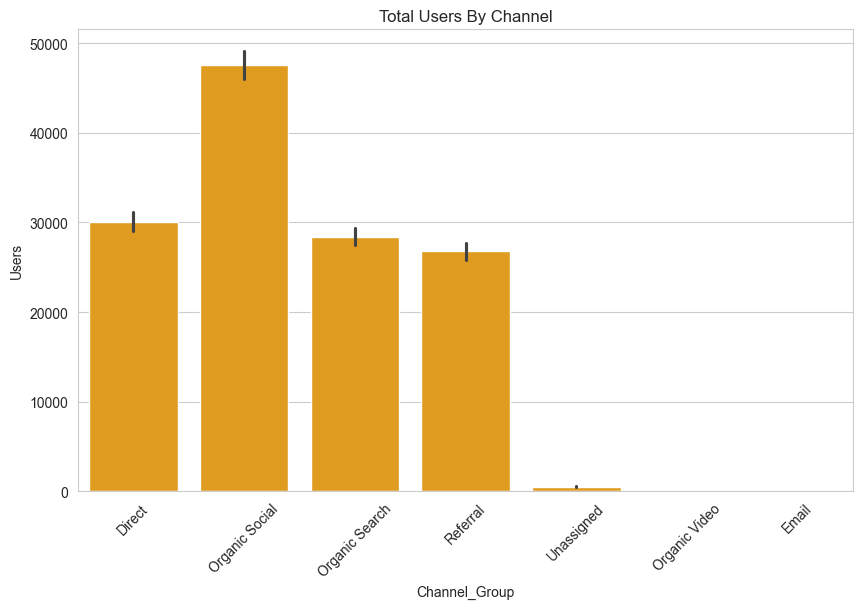

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(data = data , x = 'Channel_Group' , y = 'Users' , estimator=np.sum , color='orange' )
plt.title('Total Users By Channel')
plt.xticks(rotation = 45)
plt.show()

# 3. Which Channel Has the highest Average Engagement Time, And What Does That Tell Us About User behaviour And Content Effectiveness?

C:\Users\legen\AppData\Local\Temp\ipykernel_8928\3634634543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = data , x = 'Channel_Group' , y = 'Average_Engagement_This_Per_Session' , estimator=np.mean , palette='Set2')


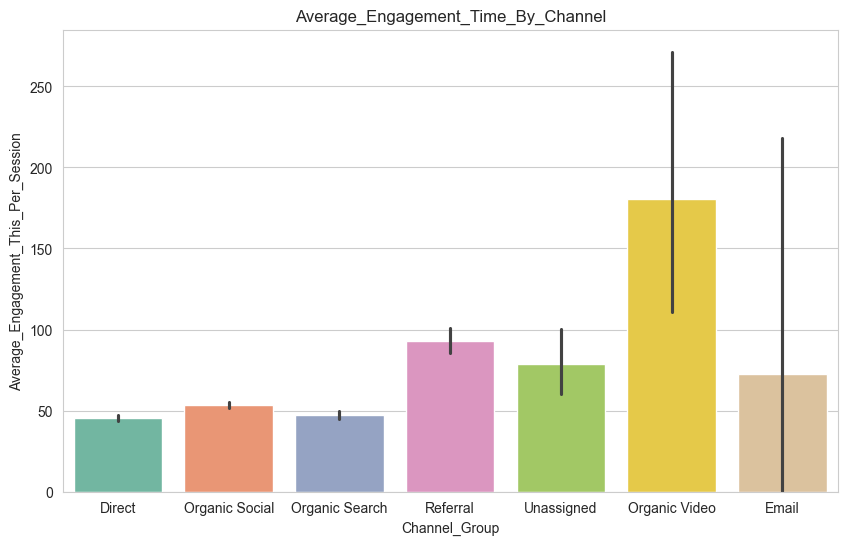

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data = data , x = 'Channel_Group' , y = 'Average_Engagement_This_Per_Session' , estimator=np.mean , palette='Set2')
plt.title('Average_Engagement_Time_By_Channel')
plt.show()

<Axes: xlabel='Channel_Group'>

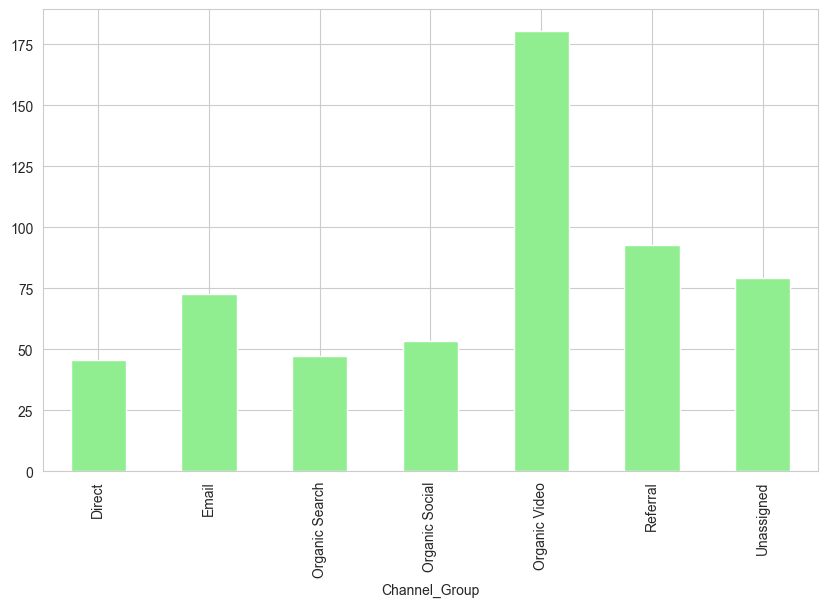

In [ ]:
#2nd Method...


plt.figure(figsize = (10,6))
data.groupby('Channel_Group')['Average_Engagement_This_Per_Session'].mean().plot(kind='bar' , color='lightgreen')

# 4. How Does Engagement Rate Vary Across Different Tarffic Channels?

C:\Users\legen\AppData\Local\Temp\ipykernel_8928\3046945173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data , x ='Channel_Group' , y = 'Engagement_Rate' , palette='Set2')


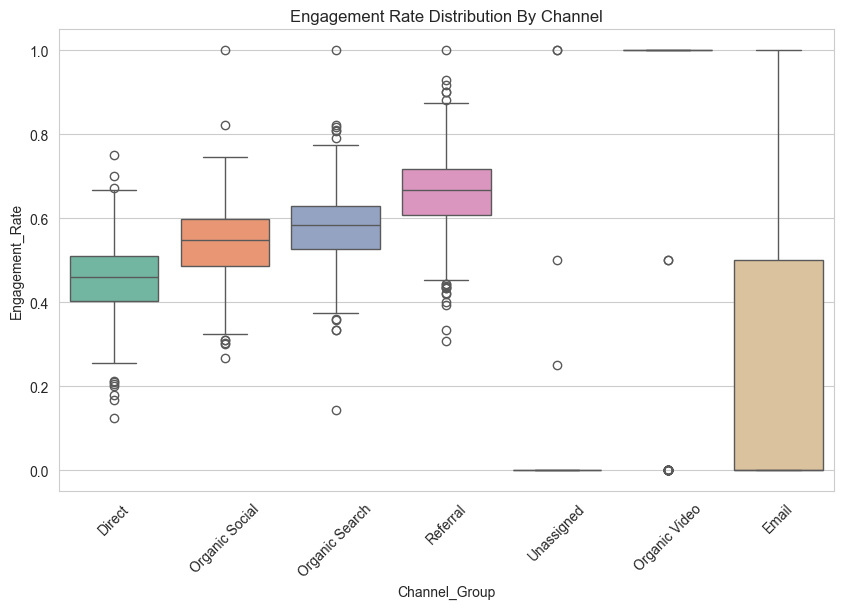

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data = data , x ='Channel_Group' , y = 'Engagement_Rate' , palette='Set2')
plt.title('Engagement Rate Distribution By Channel')
plt.xticks(rotation = 45)
plt.show()

# 5. Which Channel Are Driving More Engaged Sessions Compared To Non-Engaged Ones, And What Strategies Can Improve Engagement In UnderPerforming Channnels?

In [13]:
data['Non_Engaged'] = (data['Sessions'] - data['Engaged_Sessions'])

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Direct'),
  Text(1, 0, 'Email'),
  Text(2, 0, 'Organic Search'),
  Text(3, 0, 'Organic Social'),
  Text(4, 0, 'Organic Video'),
  Text(5, 0, 'Referral'),
  Text(6, 0, 'Unassigned')])

<Figure size 1000x600 with 0 Axes>

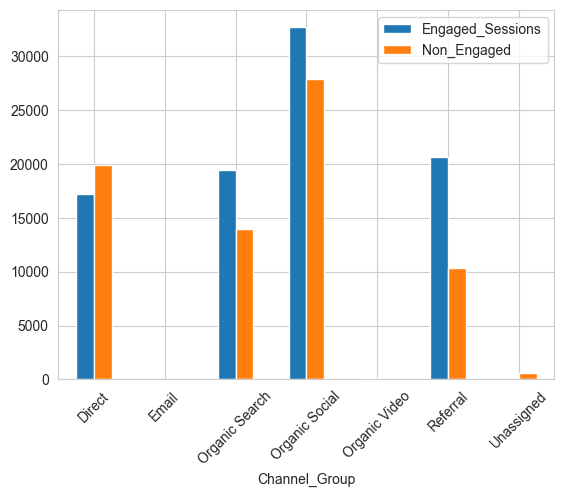

In [14]:
plt.figure(figsize = (10,6))
data.groupby('Channel_Group')[['Engaged_Sessions' , 'Non_Engaged']].sum().plot(kind='bar')
plt.xticks(rotation = 45 , fontsize = 10)

# 6. At What Hours Of The Day Does Each Channel Drive The Most Traffic?

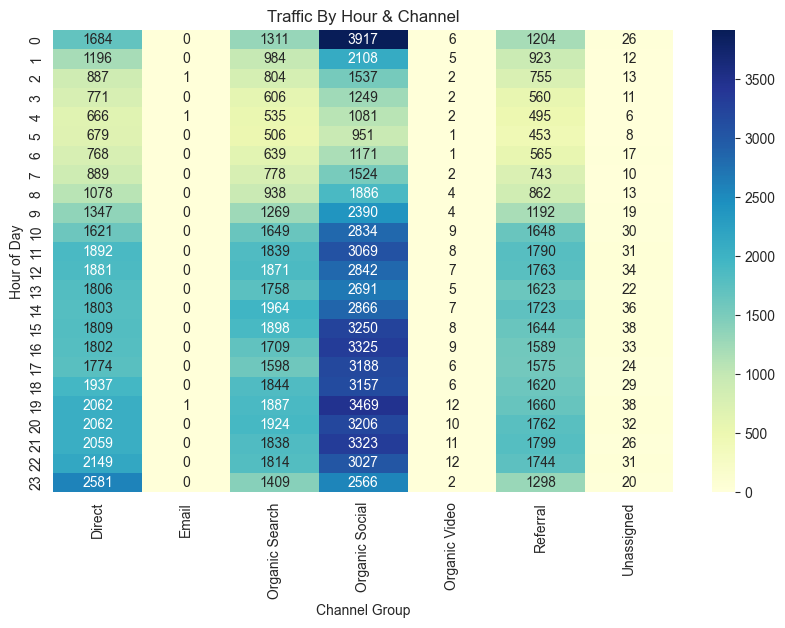

In [15]:
heatmap_data = data.groupby(['Hours' , 'Channel_Group'])['Sessions'].sum().unstack().fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True , cmap='YlGnBu' , fmt='.0f')
plt.title('Traffic By Hour & Channel')
plt.xlabel('Channel Group')
plt.ylabel('Hour of Day')
plt.show()

# 7.Is There Any Correaltion Between High Traffic (Sessions) And High Engagement Rate Over Time?

<Figure size 1000x600 with 0 Axes>

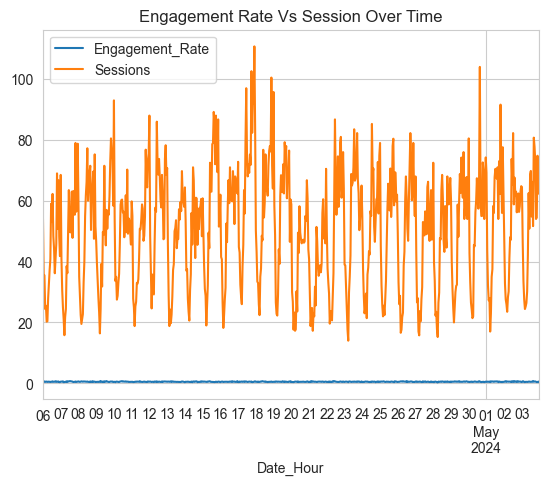

In [32]:
sns.set_style('whitegrid')

plt.figure(figsize=(10,6))
data.groupby('Date_Hour')[['Engagement_Rate' ,'Sessions']].mean().plot().reset_position
plt.title('Engagement Rate Vs Session Over Time')
plt.show()